# D'Hondt Vote Simulator

D'Hondt's method works like this: you have $N$ seats and voters each vote for one party. Each party's score $x$ is given by $X / (s + 1)$ where $X$ is the percentage of the vote they got and $s$ is the number of seats they have already won. Give seats to each party until we have all $N$ seats. 

Suppose you have polling for the likely ranges of the vote share each party will get. How can we see how increasing the vote share in one party (by voting for them) will affect the number of seats each party gets? The goal is a matrix where the row lists who we vote for and the column lists the effect voting for that party has on that other party's expected number of seats. For simplicity we will assume "Independents" are a single parrty. 

### Imports & seeding

In [1]:
import random as r
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
r.seed(1)

### Parameters

In [2]:
num_seats = 6
swing_size = 1 #Seeing how a change of this size affects results
num_trials = 10 ** 5 #How many simulated elections we compare the effects of a swing for each party for


names = [
    "Plaid",
    "Reform",
    "Labour",
    "Greens",
    "Conservatives",
    "Liberal Democrats",
    "Independents"
]

'''
Bounds gives the approximately plausible range of vote share for each party
'''
bounds = [
    [24, 31], #yellow
    [22, 30], #cyan
    [14, 21], #red
    [9, 15], #green
    [8, 18], #blue
    [3, 7], #orange
    [1, 6] #purple
]

### Algorithm Logic

In [3]:
#get figures in the ranges
def vote():
    votes = [r.uniform(bounds[i][0], bounds[i][1]) for i in range(len(bounds))]
    #Reset very implausible results - can adjust to trade runtime for precision
    while sum(votes) < 90 or sum(votes) > 110:
        votes = [r.uniform(bounds[i][0], bounds[i][1]) for i in range(len(bounds))]
    return(votes)
    
#perform D'Hondt's algorithm on the proportion of vote share
def dhondt(votes):
    seats = [0 for x in bounds]
    while sum(seats) < num_seats:
        scores = [votes[i] / (seats[i] + 1) for i in range(len(seats))]
        for i in range(len(seats)):
            if scores[i] == max(scores):
                seats[i] += 1
    return(seats)

### How does a small swing change results?

In [4]:
'''
If we increase the party_number-th party's vote share by swing_size, how does this affect the result? 
'''
def swing_effect(party_number):
    #Vote shares
    base_votes = vote()
    swing_votes = [base_votes[i] + swing_size if i == party_number else base_votes[i] for i in range(len(base_votes))]

    #Results of those shares
    base_results = dhondt(base_votes)
    swing_results = dhondt(swing_votes)
    return([swing_results[i] - base_results[i] for i in range(len(base_results))])

results_matrix = [
    [0 for n in range(len(bounds))] for m in range(len(bounds))
]

#Run simulation
for i in tqdm(range(num_trials)):
    for j in range(len(bounds)):
        swing = swing_effect(j)
        for k in range(len(swing)):
            results_matrix[j][k] += swing[k]

#Normalize
results_matrix = [
    [x / num_trials for x in row] for row in results_matrix
]

for row in results_matrix:
    print(row)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100000/100000 [00:31<00:00, 3220.61it/s]

[0.03342, -0.01004, -0.00157, -0.01446, -0.00735, 0.0, 0.0]
[-0.01266, 0.055, -0.00072, -0.02734, -0.01428, 0.0, 0.0]
[-0.00186, -0.00059, 0.01371, -0.00742, -0.00384, 0.0, 0.0]
[-0.03342, -0.0609, -0.00999, 0.15561, -0.0513, 0.0, 0.0]
[-0.01708, -0.03251, -0.00505, -0.05445, 0.10909, 0.0, 0.0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


### Heatmap of results

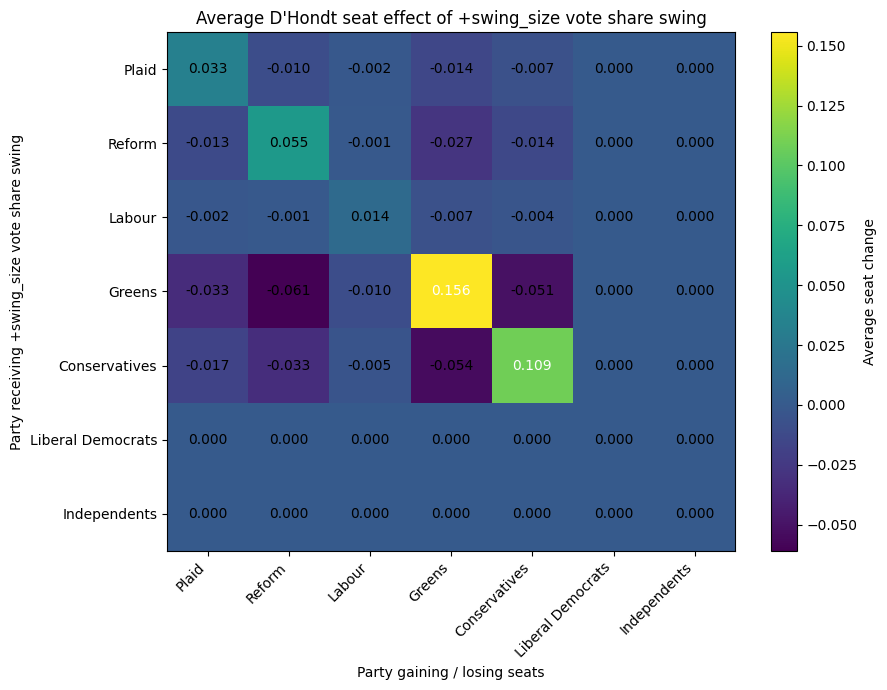

In [5]:
matrix = np.array(results_matrix)
fig, ax = plt.subplots(figsize = (9, 7))
im = ax.imshow(matrix, aspect = "auto")
ax.set_xticks(np.arange(len(names)))
ax.set_yticks(np.arange(len(names)))
ax.set_xticklabels(names, rotation = 45, ha = "right")
ax.set_yticklabels(names)
ax.set_xlabel("Party gaining / losing seats")
ax.set_ylabel("Party receiving +swing_size vote share swing")
ax.set_title("Average D'Hondt seat effect of +swing_size vote share swing")

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        ax.text(
            j, i,
            f"{matrix[i, j]:.3f}",
            ha = "center",
            va = "center",
            color = "white" if abs(matrix[i, j]) > np.nanmax(abs(matrix)) / 2 else "black"
        )

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Average seat change")
plt.tight_layout()
plt.show()